In [1]:
import numpy as np
import matplotlib.pyplot as plt

from zeroheliumkit import GeomCollection, Rectangle
from zeroheliumkit.src.importing import Reader_Pickle
from zeroheliumkit.src.settings import *

from zeroheliumkit.fem.fieldreader import FreeFemResultParser, FieldAnalyzer
from zeroheliumkit.fem.fieldreader import make_cropped, make_masked, make_smooth, make_symmetric
from zeroheliumkit.src.settings import BLACK, WHITE
from zeroheliumkit.helpers.constants import qe, me, hbar

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [3]:
dir = "width_600nm/"
ffparser = FreeFemResultParser(dir + "metadata.yaml", show=True)
ffparser.get_capacitance_matrix()

FileNotFoundError: [Errno 2] No such file or directory: 'width_600nm/metadata.yaml'

In [3]:
ffparser.load_data(dir + "results/", "result2")

In [ ]:
cc1 = ffparser.get_coupling_constants(slice_value=0.26, round_with_decimals=6)

# this below is optional, but it can be useful to make the data symmetric and smooth before cropping
cc2 = make_symmetric(cc1, axis='x', symmetric_electrodes=['ch', 'a', 'b', 'c', 'res', 'top'])
cc3 = make_smooth(cc2, sigma=2.0)
cc4 = make_cropped(cc3, xrange=(-0.25,1), yrange=(-0.3,0.3))
# cc5 = make_masked(cc4, mask_area=Rectangle(0.4, 0.4, (0.6,0)))

In [5]:
fa = FieldAnalyzer(cc4)
device = GeomCollection(layers=Reader_Pickle(dir + "geo/dot.pickle").geometries)
device.top.color = (None, 0.0)
device.bottom.color = (None, 0.)

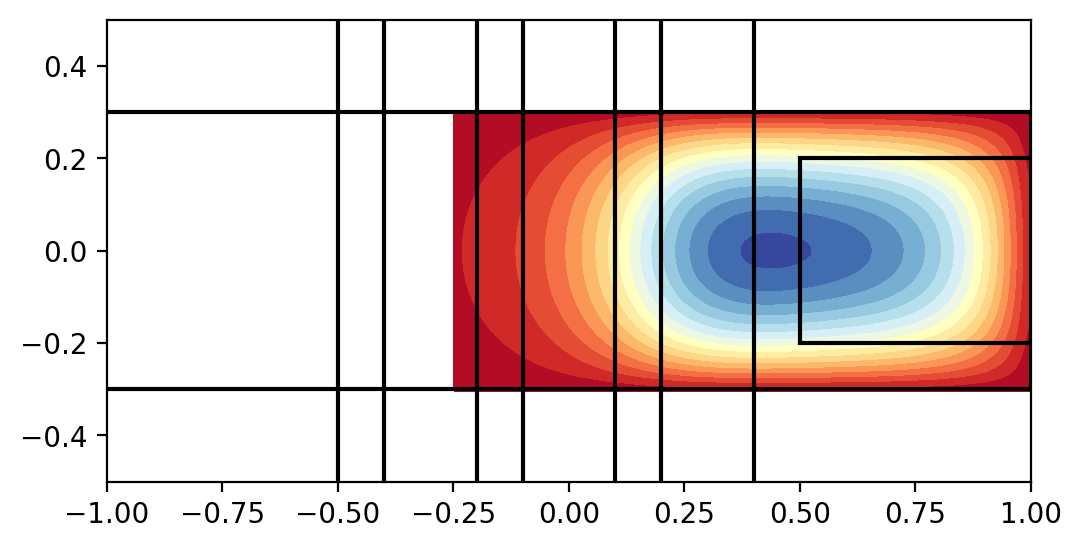

In [7]:
voltages = {
    'ch':       0,
    'a':        0, 
    'b':        0,
    'c':        0.012,
    'res':      0.01,
    'top':      0,
}

fig = plt.figure(figsize=(8, 3))
ax = fig.add_subplot(111)

fa.set_voltages(voltages)
fa.plot2D_data(ax=ax, zero_line=False, cmap='RdYlBu')
device.top.plot(ax=ax, edgecolor=BLACK)
device.bottom.plot(ax=ax, edgecolor=LIGHTGRAY)
ax.set_xlim(-1., 1.)
ax.set_ylim(-0.5, 0.5)
ax.set_aspect("equal")

plt.show()

In [8]:
from chargequbit import TrapPotential, Resonator, ChargeQubit

In [9]:
res = Resonator(type="1/4", couplings=cc4, names=['res'], resonance_frequency=7.1e9, total_capacitance=5.25e-15)
res.get_field(0.45,0)

(array(0.86397197), array(0.))

In [10]:
qd = TrapPotential(x = cc4.x, y = cc4.y, potential = fa.potential)
qd.find_trap()
qd.well

{'exist': True,
 'ij': (np.int64(69), np.int64(38)),
 'xy': (np.float64(0.43999999999999995), np.float64(0.0)),
 'value': np.float64(0.004058190458696353),
 'type': 'max'}

array([0.00000000e+00, 9.50946699e+09, 1.88673169e+10, 1.89610484e+10,
       2.81380993e+10, 2.84453885e+10, 3.73721176e+10, 3.77720502e+10,
       3.79111277e+10, 4.66072674e+10])

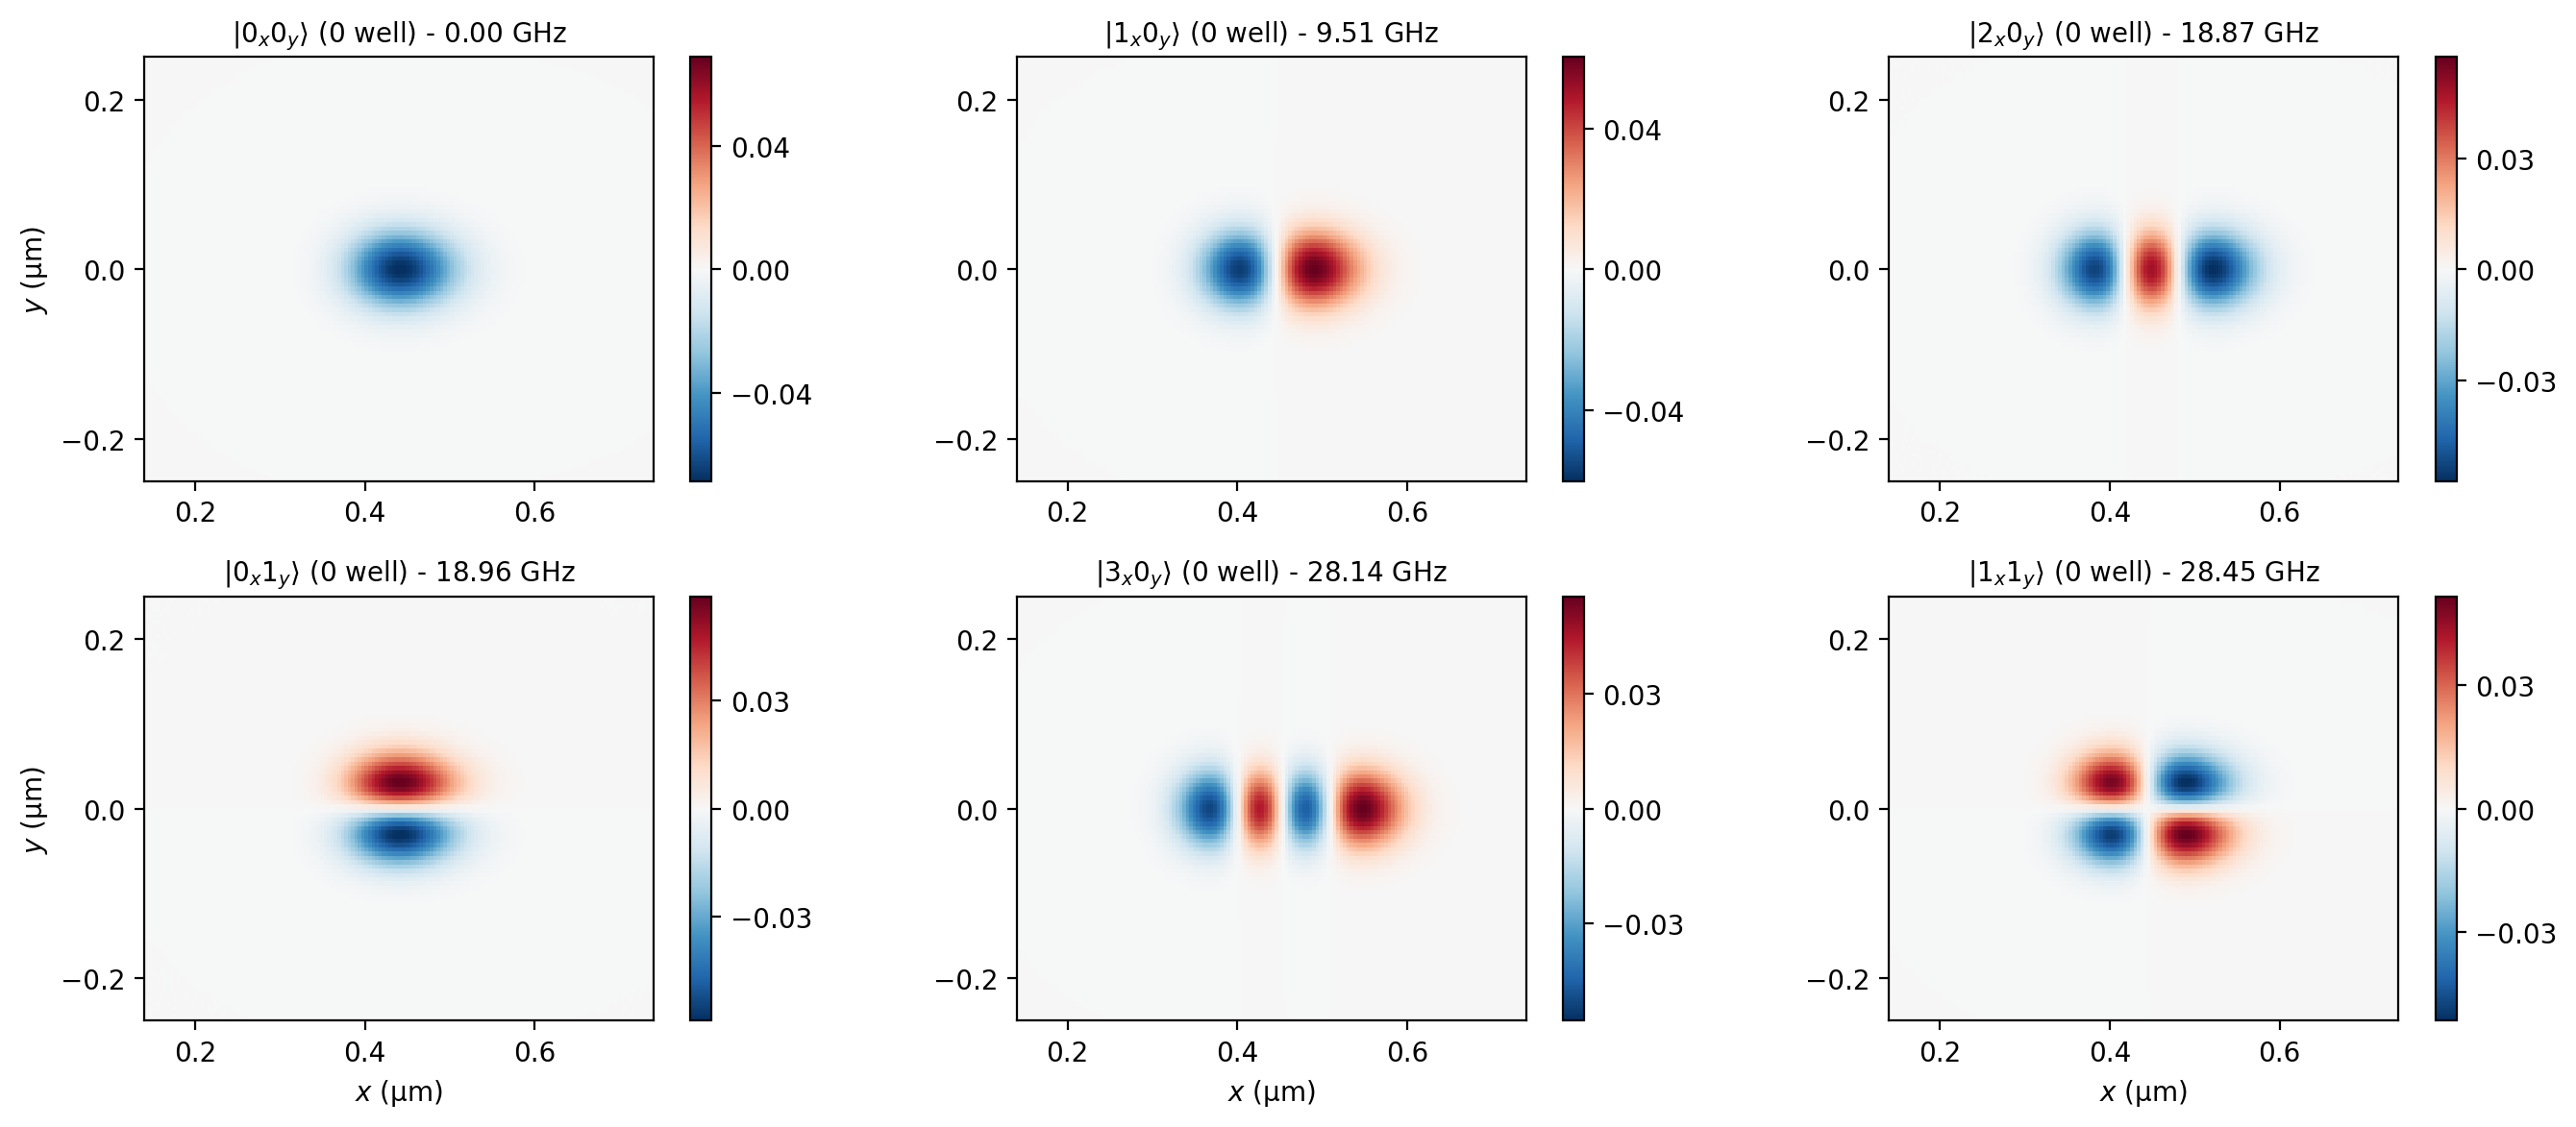

In [11]:
qp = ChargeQubit(resonator=res, trap=qd)
qp.get_spectrum(dxdy=[0.6,0.5], plot_wavefunctions=True)

In [12]:
qp.get_properties()

{'x': {'fe (GHz)': np.float64(9.509467),
  'Vzpf (uV)': np.float64(21.2),
  'le (nm)': np.float64(31.1),
  'lr (nm)': np.float64(36.0),
  'anharmonicity (MHz)': np.float64(-151.6),
  'electric_field (1/um)': 0.86,
  'coupling_g (MHz)': np.float64(159.1),
  'frequency_shift (MHz)': np.float64(-17.9697),
  'capacitance_change (aF)': np.float64(13.29)},
 'y': {'fe (GHz)': np.float64(18.961048),
  'Vzpf (uV)': np.float64(21.2),
  'le (nm)': np.float64(31.1),
  'lr (nm)': np.float64(36.0),
  'anharmonicity (MHz)': np.float64(-11.0),
  'electric_field (1/um)': 0.0,
  'coupling_g (MHz)': np.float64(0.0),
  'frequency_shift (MHz)': np.float64(-0.0),
  'capacitance_change (aF)': np.float64(0.0)}}